<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Co2_MtCO2                            4180 non-null   float64
 1   Population                           4180 non-null   float64
 2   GDP                                  4180 non-null   float64
 3   Industry_on_GDP                      4180 non-null   float64
 4   Government_Expenditure_on_Education  4180 non-null   float64
 5   Global_Climate_Risk_Index            4180 non-null   float64
 6   HDI                                  4180 non-null   float64
 7   Renewable_Energy_Percent             4180 non-null   float64
 8   Deforest_Percent                     4180 non-null   float64
 9   Energy_Capita_kWh                    4180 non-null   float64
dtypes: float64(10)
memory usage: 326.7 KB
Kích thước tập Train (đã xử lý): (3344, 9)
Kích thước tập 

<Figure size 1000x800 with 0 Axes>

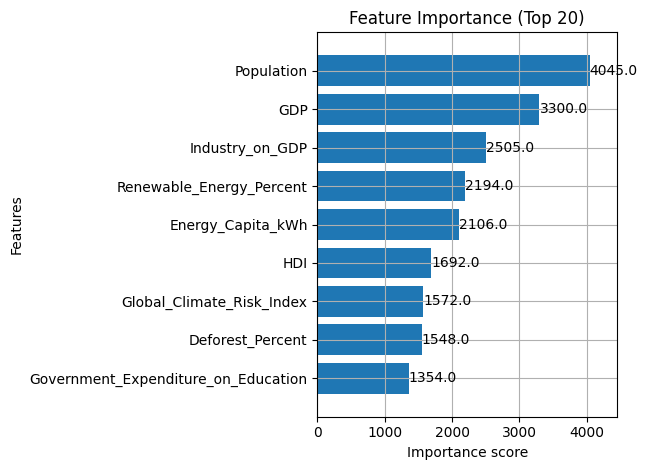

In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import joblib
# 1. Tải dữ liệu
df = pd.read_csv(r"../../Data/filled_data.csv")

# 2. [MỚI] Lọc DataFrame để chỉ giữ các cột mong muốn
columns_to_keep = [
    'Co2_MtCO2',
    'Population',
    'GDP',
    'Industry_on_GDP',
    'Government_Expenditure_on_Education',
    'Global_Climate_Risk_Index',
    'HDI',
    'Renewable_Energy_Percent',
    'Deforest_Percent',
    'Energy_Capita_kWh'
]

# Ghi đè df cũ bằng df mới đã được lọc
df = df[columns_to_keep]


df.info()

# 3. Định nghĩa Feature (X) và Target (y)
# Target y
y = df['Co2_MtCO2']

# Features X

# vì df chỉ còn các cột trong columns_to_keep
X = df.drop(columns=['Co2_MtCO2'])
    

# 5. Chia dữ liệu thành tập Train và Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train (đã xử lý): {X_train.shape}")
print(f"Kích thước tập Test (đã xử lý): {X_test.shape}")
print(f"Số lượng features sau khi get_dummies: {X_train.shape[1]}")

# 6. Khởi tạo và Huấn luyện Model
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    random_state=42,
)

print("\nBắt đầu huấn luyện mô hình XGBoost...")

# Huấn luyện mô hình
xgb_reg.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Huấn luyện hoàn tất!")

# 7. Đánh giá Model
y_pred = xgb_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print("\n--- Kết quả Đánh giá Model ---")
# print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")


# 1. Lưu Model (.joblib)
model_filename = 'best_xgboost_co2.joblib'
joblib.dump(xgb_reg, model_filename)
print(f"1. Đã lưu model tại: {model_filename}")

# 2. Lưu danh sách Features (.joblib)
# Việc này cực kỳ quan trọng để đảm bảo thứ tự cột khi predict giống hệt lúc train
features_filename = 'model_features.joblib'
joblib.dump(list(X_train.columns), features_filename)
print(f"2. Đã lưu danh sách features tại: {features_filename}")

print("--- HOÀN TẤT ---")
# 8. Trực quan hóa độ quan trọng của Feature
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_reg, max_num_features=12, height=0.8) # Hiển thị top 20
plt.title('Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

In [4]:


def predict_co2_emission(input_data):
    """
    Hàm load model và dự đoán CO2 dựa trên dictionary đầu vào.
    """
    try:
        # 1. Load Model và Features list
        print("Đang tải model và cấu hình...")
        model = joblib.load('best_xgboost_co2.joblib')
        feature_names = joblib.load('model_features.joblib')
        
        # 2. Chuyển đổi dữ liệu input thành DataFrame
        input_df = pd.DataFrame([input_data])
        
        # 3. [QUAN TRỌNG] Sắp xếp lại cột cho đúng thứ tự lúc Train
        input_df = input_df[feature_names]
        
        # 4. Thực hiện dự đoán
        print("Đang dự đoán...")
        prediction = model.predict(input_df)
        
        return prediction[0]

    except FileNotFoundError:
        return "Lỗi: Không tìm thấy file model (.joblib). Hãy chạy file train trước."
    except Exception as e:
        return f"Lỗi không xác định: {str(e)}"

sample_data = {
    'Population': 98000000,           
    'GDP': 350000000000,              
    'Industry_on_GDP': 30.5,          
    'Government_Expenditure_on_Education': 4.5,
    'Global_Climate_Risk_Index': 25.0, 
    'HDI': 0.704,                     
    'Renewable_Energy_Percent': 15.2, 
    'Deforest_Percent': 0.5,          
    'Energy_Capita_kWh': 2500.0       
}

if __name__ == "__main__":
    result = predict_co2_emission(sample_data)
    
    if isinstance(result, (float, int)):
        print("-" * 30)
        print(f"KẾT QUẢ DỰ ĐOÁN CO2: {result:,.2f} MtCO2")
        print("-" * 30)
    else:
        print(result)

Đang tải model và cấu hình...
Đang dự đoán...
148.29913
